In [1]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)

# ----------------------------------------------------

In [2]:
import math
import torch
import numpy as np
import phantom as pt
import IR_UTE as ute
import torchkbnufft as tkbn
import randialSampling as rs
import matplotlib.pyplot as plt


# create phantom
img_size = 256
inner_size = 80
mixed_size = 160
upper_square_size = 20
outer_size = 190

# values in seconds
t1_wm = 0.8       
t2_wm = 0.08
t1_myelin = 0.226         
t2_myelin = 300 * 1e-6

# Time Step
dt = 10 # unite: us

# Off-resonance frequencies
df = np.linspace(-500, 500, 200)

TE1 = 8 # us
TE2 = 2.2 * 1e3 # us

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 1. Create Virtual Phantom

### (1) Myelin (T1 map, T2 map, Probability map)

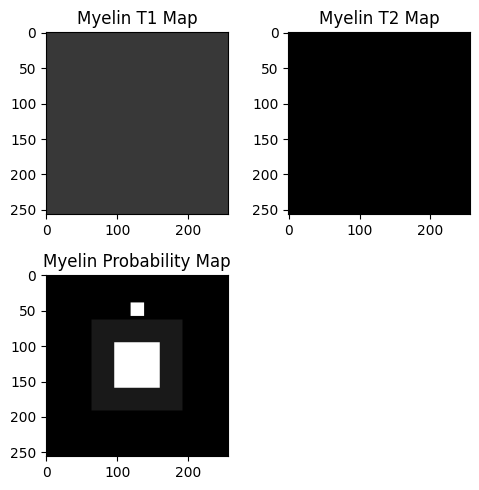

In [3]:
inner_myelin = 1
mixed_myelin = 0.1
outer_myelin = 0

myelin = pt.VirtualPhantom(img_size)
t1_map_myelin, t2_map_myelin, prob_map_myelin = myelin.create_maps(t1_myelin, t2_myelin, inner_myelin, mixed_myelin, outer_myelin, upper_sqaure=True)
myelin.phantom_display('Myelin')

### (2) White Matter (T1 map, T2 map, Probability map)

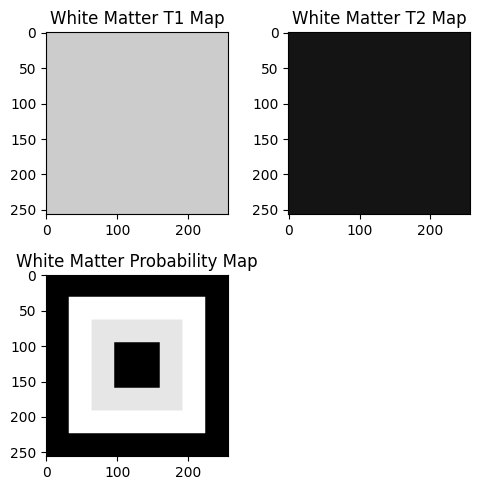

In [4]:
inner_wm = 0
mixed_wm = 0.9
outer_wm = 1

wm = pt.VirtualPhantom(img_size)
t1_map_wm, t2_map_wm, prob_map_wm = wm.create_maps(t1_wm, t2_wm, inner_wm, mixed_wm, outer_wm, upper_sqaure = True)
wm.phantom_display('White Matter')

## 2. IR-UTE Simulation

In [7]:
n_readout = 30
t_readout = 0.768 * 1e-3
t_nullout = int(0.55066 * 1e6)
flip_angle = torch.pi/18*2

### (1） White Matter IR-UTE

In [8]:
wm = ute.IR_UTE(dt, df, t1_wm, t2_wm)
m_ir = wm.inversion_recovery()

### ----------- calculate TI ---------------
#t_nullout = wm.calculate_nulling_point()
#print(t_nullout)
### ----------------------------------------

full_mag_series_wm, excitation_time_wm, mag_readout_start_wm_TE1, mag_readout_start_wm_TE2, t_mag_readout_start_wm_TE1, t_mag_readout_start_wm_TE2 = wm.transverse_excitation_dual_echo(n_readout, t_readout, t_nullout, flip_angle, TE1, TE2)

t_readout_end_index: 497
write_start: 0
initial_mag: [-7.12628625e-06  1.57332263e-05  6.41675557e-07]
Angle=0.3490658503988659, M after 1 step: [-7.12787890e-06  1.57376129e-05  1.31326331e-05]
write_start: 497
initial_mag: [0.         0.         0.00617312]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 3.52104663e-06 6.18554067e-03]
write_start: 994
initial_mag: [0.         0.         0.01192768]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 6.79672001e-06 1.19400259e-02]
write_start: 1491
initial_mag: [0.         0.         0.01728755]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 9.84772552e-06 1.72998296e-02]
write_start: 1988
initial_mag: [0.        0.        0.0222798]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 1.26894724e-05 2.22920216e-02]
write_start: 2485
initial_mag: [0.         0.         0.02692966]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 1.53363131e-05 2.69418153e-02]
write_start: 2982
initial_mag: [0. 

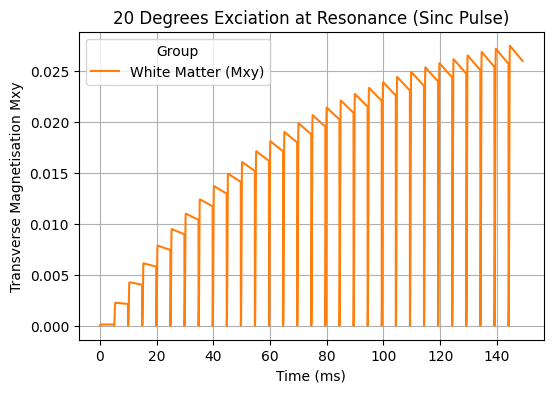

In [20]:
title = 'White Matter (Mxy)'
#wm.magnetization_display_xy(full_mag_series_wm, title)




# details of the magnetization_display_xy function
magnetization_xy = np.sqrt(np.power(full_mag_series_wm[wm.n_on_resonance, :, 0], 2) + np.power(full_mag_series_wm[wm.n_on_resonance, :, 1], 2))
n_steps =  full_mag_series_wm.shape[1]

time = np.arange(n_steps) * wm.dt * 1e-3  # micro seconds
plt.figure(figsize=(6,4))
plt.plot(time[:wm.readout_ends], magnetization_xy[:wm.readout_ends],  color = 'tab:orange', label= title)

plt.xlabel('Time (ms)')
plt.ylabel('Transverse Magnetisation Mxy')
#plt.ylim([0,1])
plt.title(f'{int(np.round(180/math.pi * wm.flip_angle))} Degrees Exciation at Resonance (Sinc Pulse)')
plt.grid(True)
plt.legend(title = "Group")
plt.show()

### (2) Myelin IR-UTE

In [21]:
myelin = ute.IR_UTE(dt, df, t1_myelin, t2_myelin)
m_ir = myelin.inversion_recovery()

full_mag_series_myelin, excitation_time_myelin, mag_readout_start_myelin_TE1, mag_readout_start_myelin_TE2, t_mag_readout_start_myelin_TE1, t_mag_readout_start_myelin_TE2 = myelin.transverse_excitation_dual_echo(n_readout, t_readout, t_nullout, flip_angle, TE1, TE2)

t_readout_end_index: 497
write_start: 0
initial_mag: [-7.41098469e-323 -7.41098469e-323  9.06149065e-001]
Angle=0.3490658503988659, M after 1 step: [-7.41098469e-323  5.14012273e-004  9.06153072e-001]
write_start: 497
initial_mag: [0.         0.         0.86718308]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.91909932e-04 8.67188820e-01]
write_start: 994
initial_mag: [0.         0.         0.83082628]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.71287577e-04 8.30833636e-01]
write_start: 1491
initial_mag: [0.         0.         0.79690396]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.52046107e-04 7.96912817e-01]
write_start: 1988
initial_mag: [0.         0.         0.76525309]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.34093057e-04 7.65263355e-01]
write_start: 2485
initial_mag: [0.         0.         0.73572158]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.17342153e-04 7.35733160e-01]
write_start: 2982
initial_

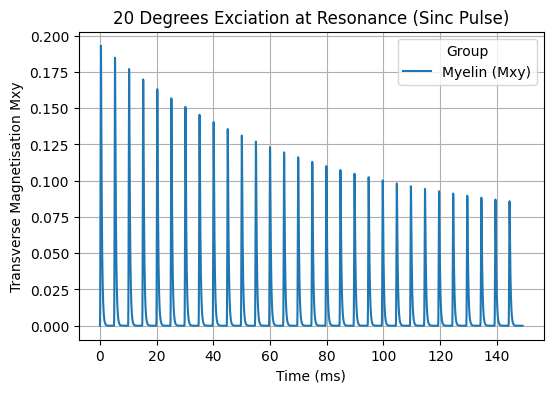

In [22]:
title = 'Myelin (Mxy)'
#myelin.magnetization_display_xy(full_mag_series_myelin, title)


# details of the magnetization_display_xy function
magnetization_xy = np.sqrt(np.power(full_mag_series_myelin[myelin.n_on_resonance, :, 0], 2) + np.power(full_mag_series_myelin[myelin.n_on_resonance, :, 1], 2))
n_steps =  full_mag_series_myelin.shape[1]

time = np.arange(n_steps) * myelin.dt * 1e-3  # micro seconds
plt.figure(figsize=(6,4))
plt.plot(time[:myelin.readout_ends], magnetization_xy[:myelin.readout_ends],  color = 'tab:blue', label= title)

plt.xlabel('Time (ms)')
plt.ylabel('Transverse Magnetisation Mxy')
#plt.ylim([0,1])
plt.title(f'{int(np.round(180/math.pi * myelin.flip_angle))} Degrees Exciation at Resonance (Sinc Pulse)')
plt.grid(True)
plt.legend(title = "Group")
plt.show()

(200, 99850, 3)


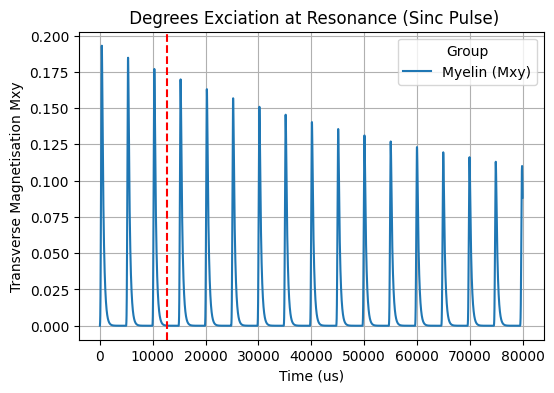

In [40]:
magnetization = full_mag_series_myelin
print(full_mag_series_myelin.shape)
magnetization_xy = np.sqrt(np.power(magnetization[100, :, 0], 2) + np.power(magnetization[100, :, 1], 2))
n_steps =  magnetization.shape[1]

time = np.arange(n_steps) * dt  # micro seconds
plt.figure(figsize=(6,4))
plt.plot(time[:8000], magnetization_xy[:8000], label= title)

plt.xlabel('Time (us)')
plt.ylabel('Transverse Magnetisation Mxy')
#plt.ylim([0,1])
plt.title(' Degrees Exciation at Resonance (Sinc Pulse)')
plt.axvline(x=(470+2200 + 3*768 + 470 + 2200 + 3*768 + 470 +2200), color='r', linestyle='--')
plt.grid(True)
plt.legend(title = "Group")
plt.show()


## 3. Radial Sampling

### (1) Visual numbers of readouts within single inversion time

#### a. Myelin

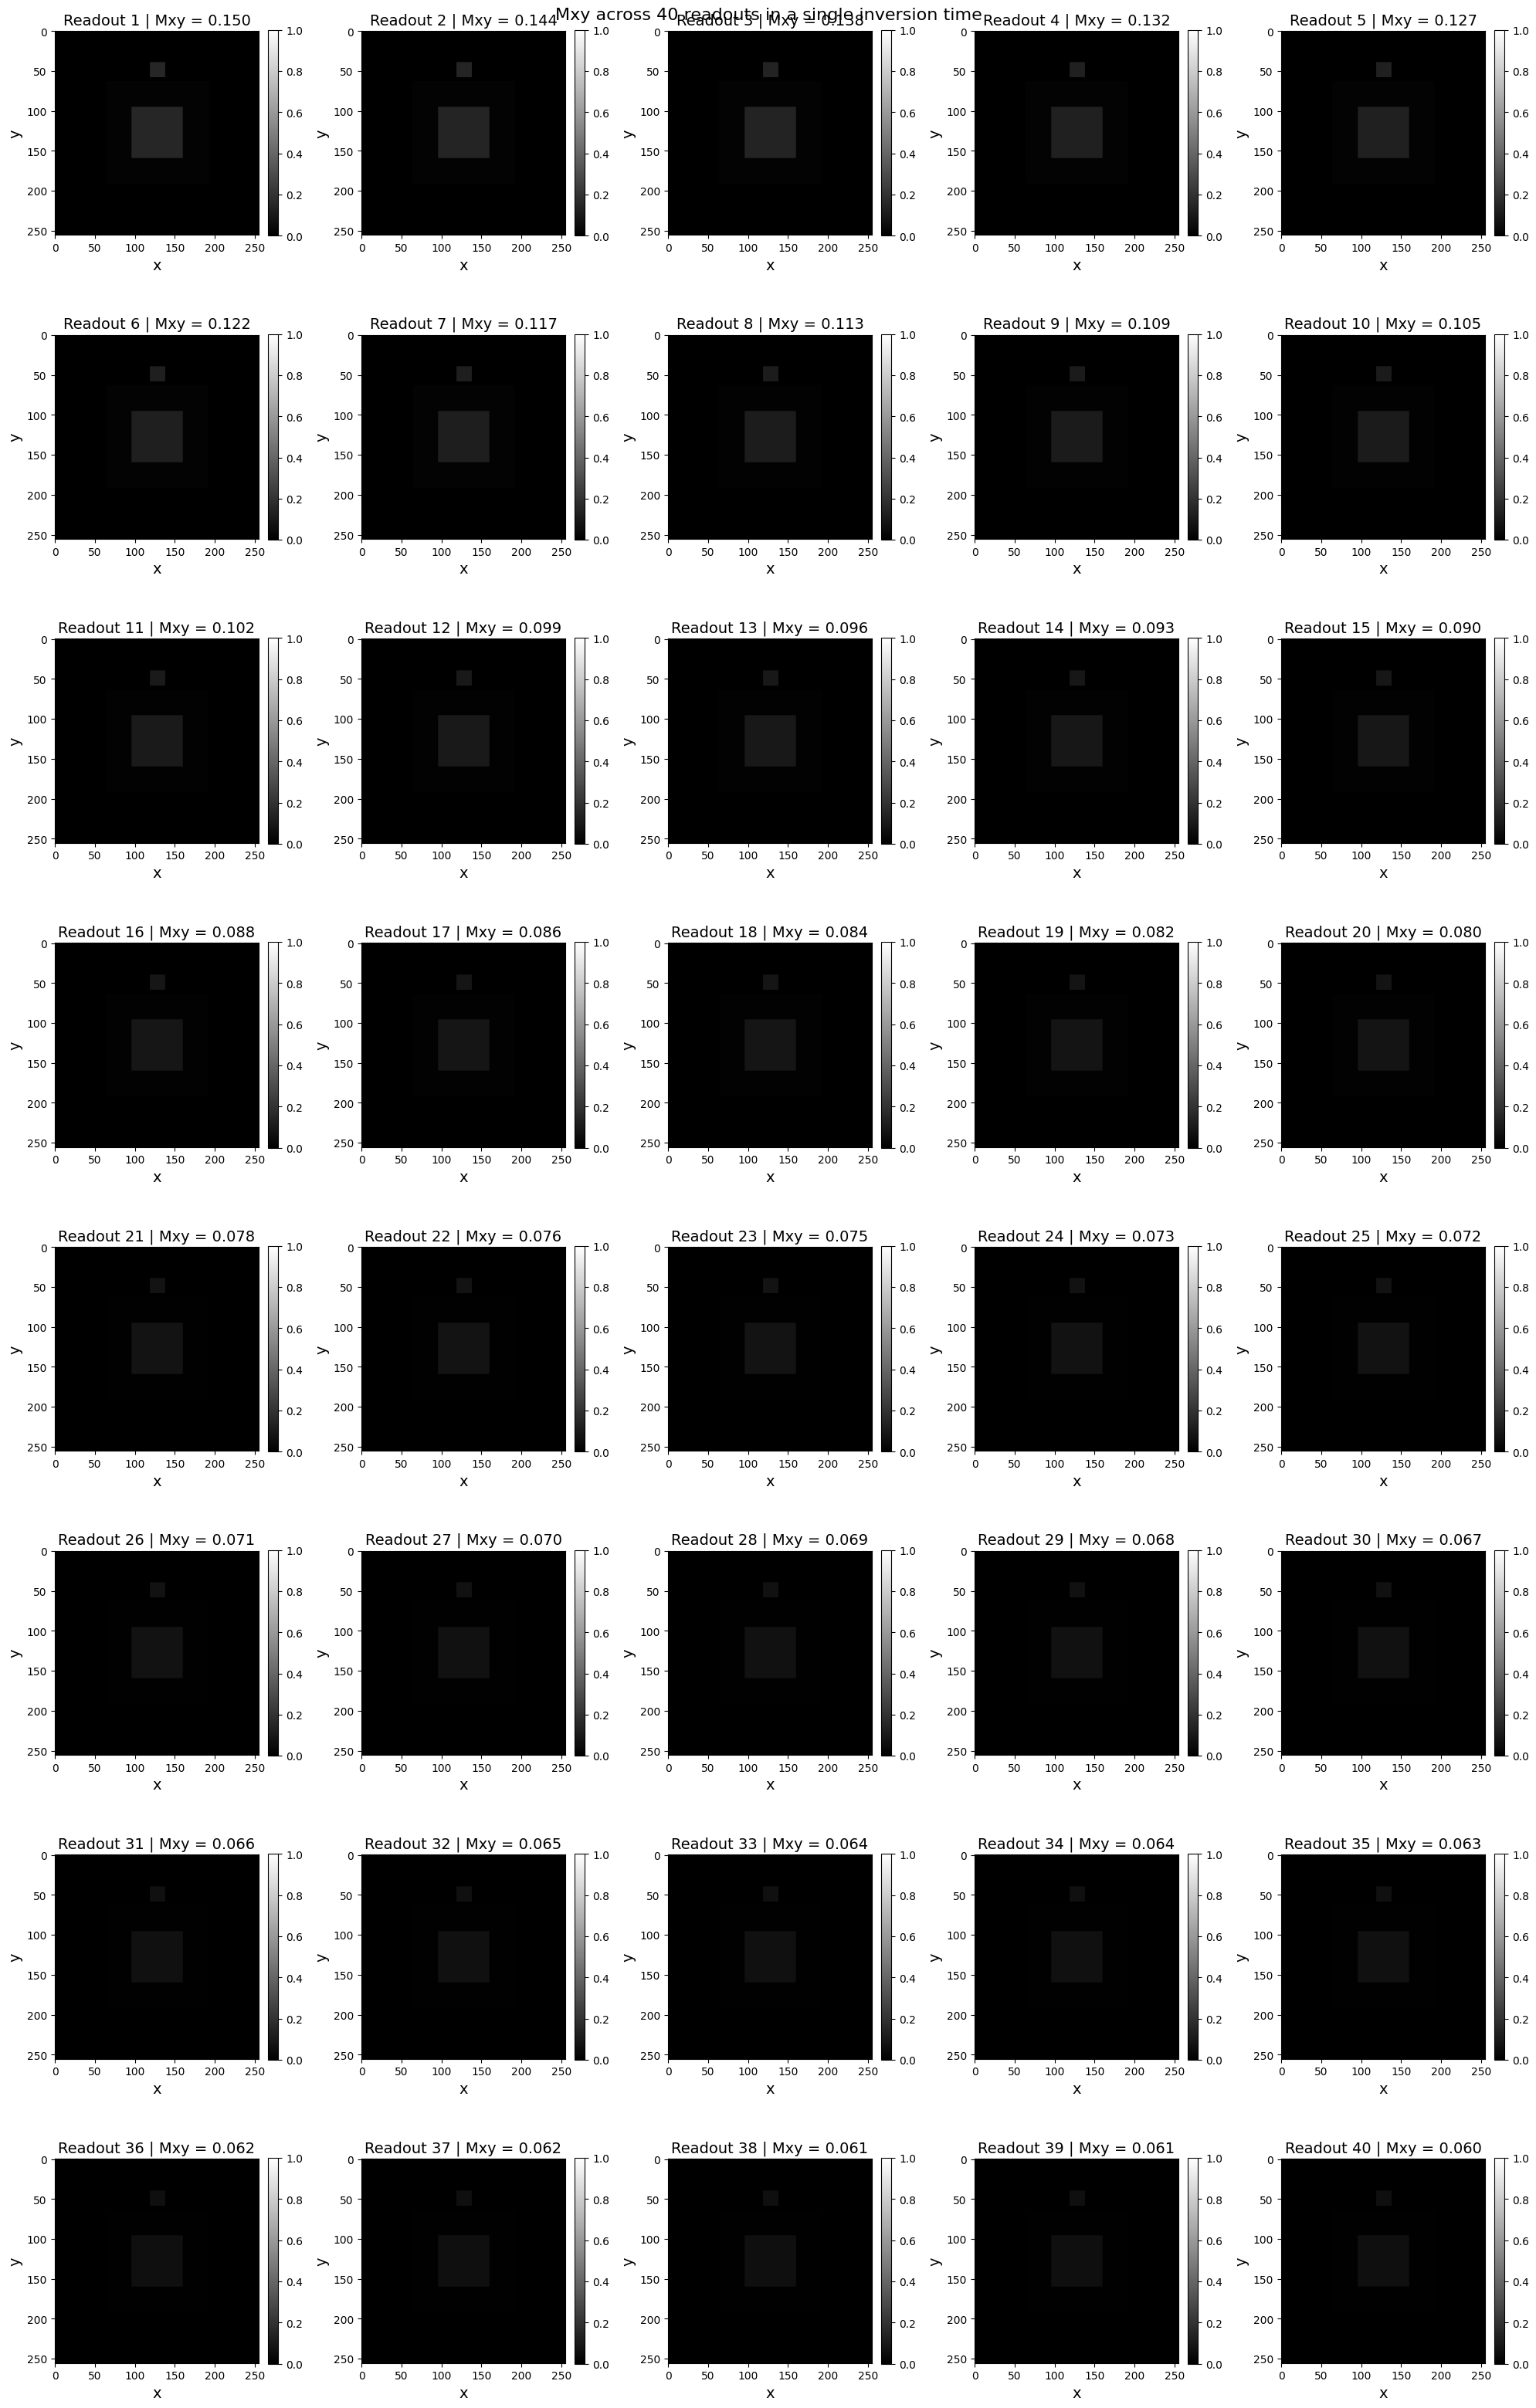

In [41]:
radial_sampling = rs.RadialSampling(img_size)
radial_sampling.visualReadoutsInSingleTI(mag_readout_start_myelin_TE1, df, prob_map_myelin)

#### b. White Matter

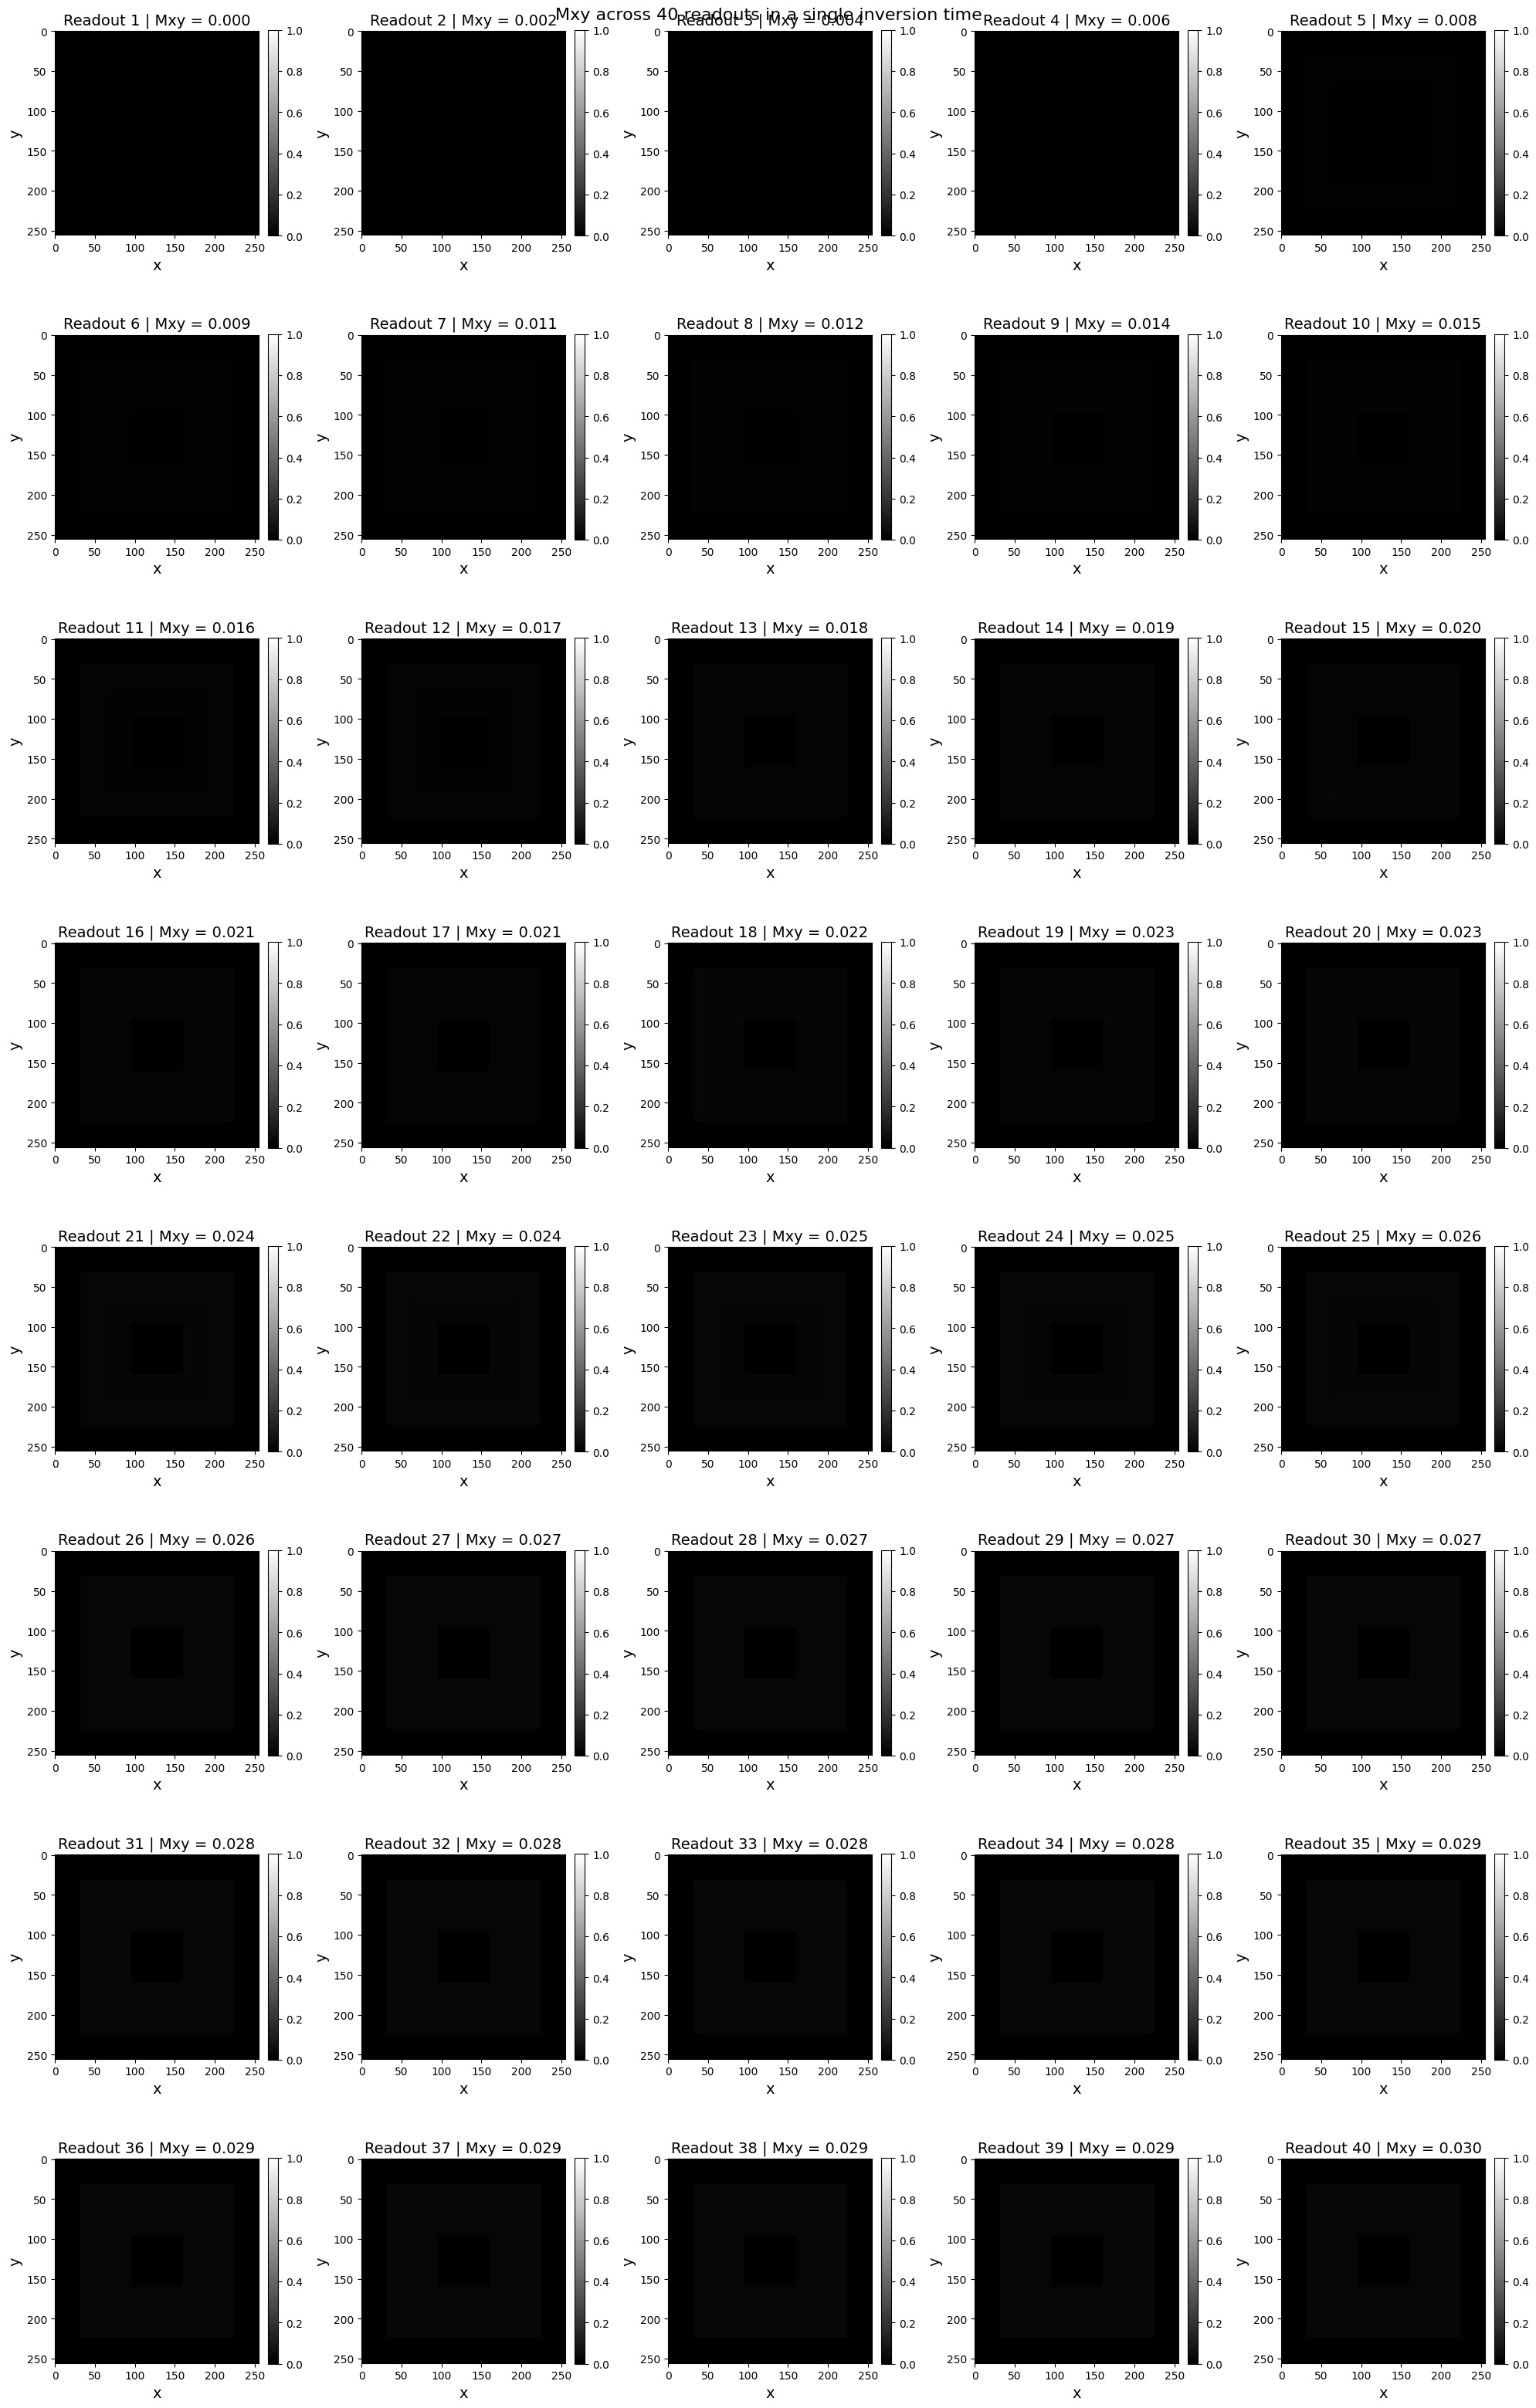

In [42]:
radial_sampling.visualReadoutsInSingleTI(mag_readout_start_wm_TE1, df, prob_map_wm)

### (2) Get kspace data and kspace trajectory
n numbers of readouts have been taken withing one inversion time, and only one spoke has been acquired from a single readout 

#### a. Myelin

In [43]:
kdata_t_myelin_TE1, ktraj_total_TE1 = radial_sampling.get_kdata_ktraj(df, mag_readout_start_myelin_TE1, prob_map_myelin, n_readout, t2_myelin, t_readout)
kdata_t_myelin_TE2, ktraj_total_TE2 = radial_sampling.get_kdata_ktraj(df, mag_readout_start_myelin_TE2, prob_map_myelin, n_readout, t2_myelin, t_readout, reverse_readout = True)

#### b. White Matter

In [44]:
kdata_t_wm_TE1, ktraj_total_TE1 = radial_sampling.get_kdata_ktraj(df, mag_readout_start_wm_TE1, prob_map_wm, n_readout, t2_wm, t_readout)
kdata_t_wm_TE2, ktraj_total_TE2 = radial_sampling.get_kdata_ktraj(df, mag_readout_start_wm_TE2, prob_map_wm, n_readout, t2_wm, t_readout, reverse_readout=True)

### (3) Log10 Kdata (without noise)

#### a. Myelin

##### (1) Centre-out readout (TE1)

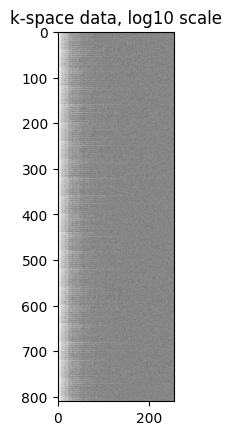

In [45]:
radial_sampling.visual_logKdata(kdata_t_myelin_TE1)

##### (2) Centre-in readout (TE2)

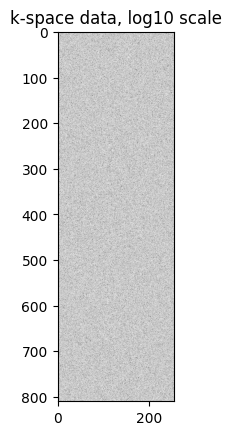

In [46]:
radial_sampling.visual_logKdata(kdata_t_myelin_TE2)

#### b. White Matter

##### (1) Centre-out readout (TE1)

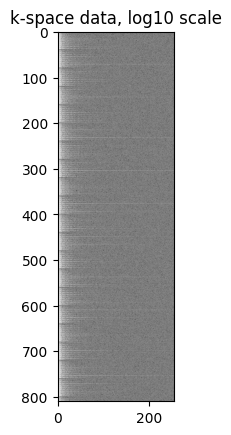

In [47]:
radial_sampling.visual_logKdata(kdata_t_wm_TE1)

##### (2) Centre-in readout (TE2)

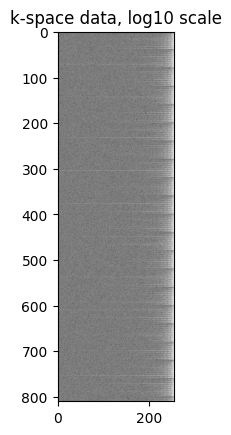

In [48]:
radial_sampling.visual_logKdata(kdata_t_wm_TE2)

### (4) Blurry and Sharp Image (use density compensation)

### 1. TE1

#### a. Myelin

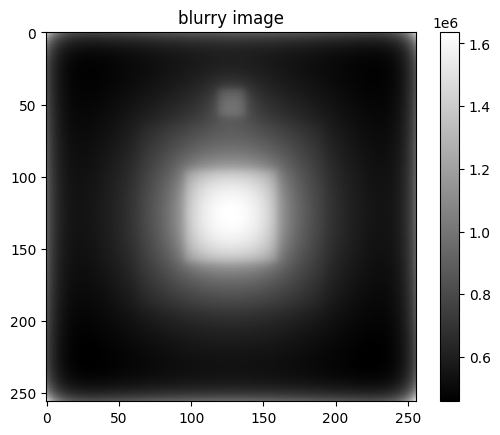

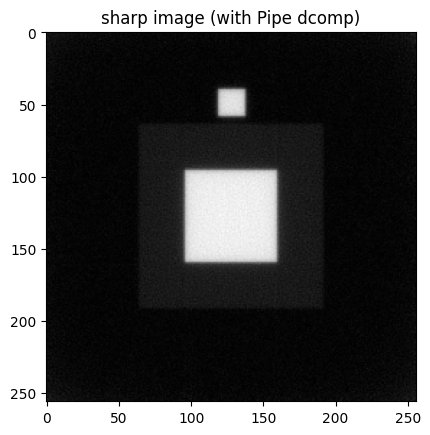

In [49]:
_, image_sharp_myelin_TE1 = radial_sampling.visual_blurry_sharp_image(kdata_t_myelin_TE1, ktraj_total_TE1)

#### b. White Matter

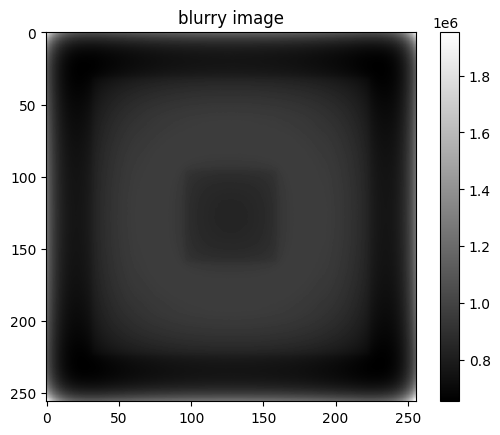

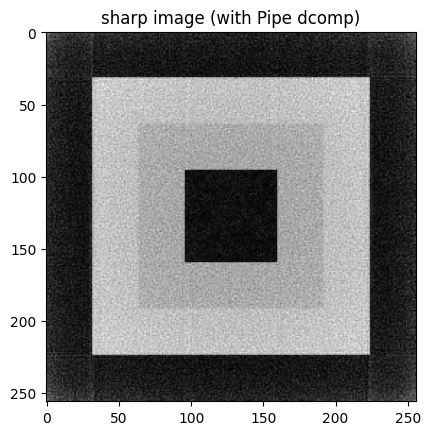

In [50]:
_, image_sharp_wm_TE1 = radial_sampling.visual_blurry_sharp_image(kdata_t_wm_TE1, ktraj_total_TE1)

#### c. Two signals combined

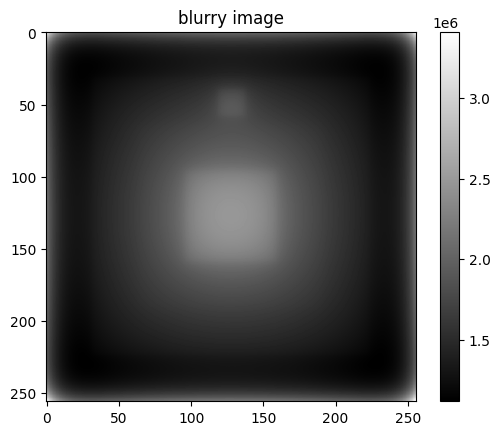

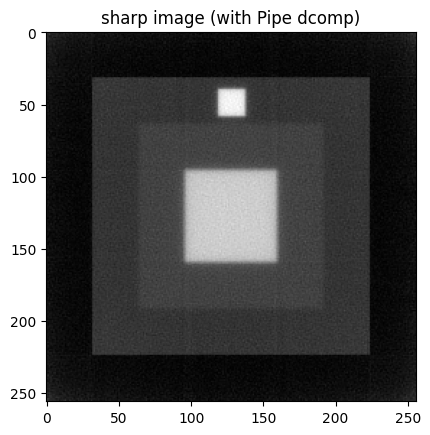

In [51]:
kdata_total_TE1 = kdata_t_myelin_TE1 + kdata_t_wm_TE1
_, image_sharp_combined_TE1 = radial_sampling.visual_blurry_sharp_image(kdata_total_TE1, ktraj_total_TE1)

### 2. TE2

#### a. Myelin

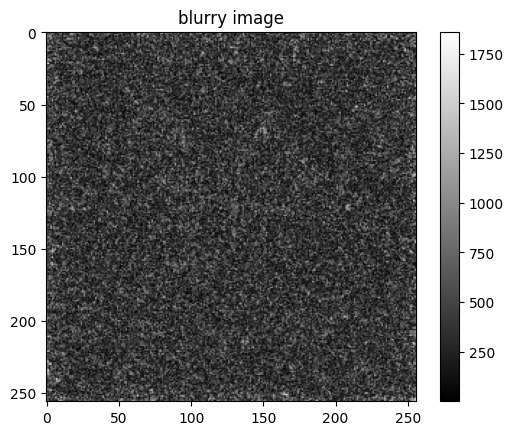

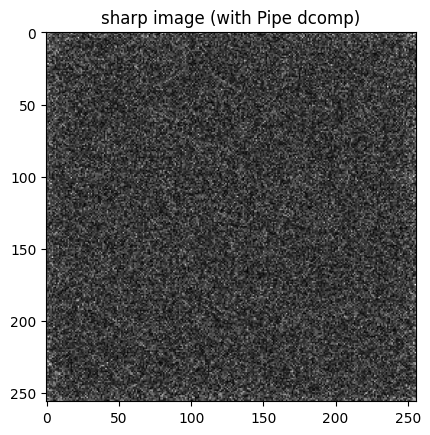

In [52]:
_, image_sharp_myelin_TE2 = radial_sampling.visual_blurry_sharp_image(kdata_t_myelin_TE2, ktraj_total_TE2)

#### b. White Matter

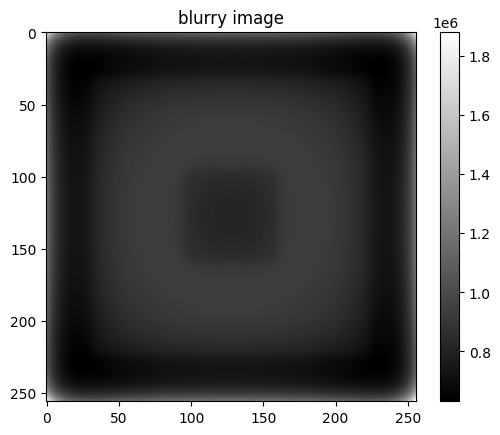

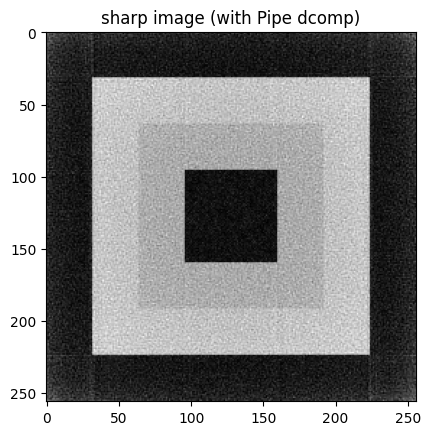

In [53]:
_, image_sharp_wm_TE2 = radial_sampling.visual_blurry_sharp_image(kdata_t_wm_TE2, ktraj_total_TE2)

#### c. Two signals combined

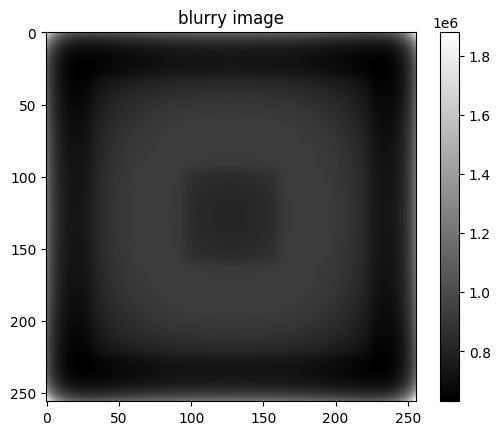

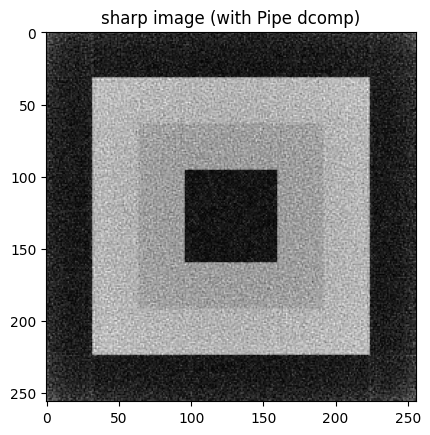

In [54]:
kdata_total_TE2 = kdata_t_myelin_TE2 + kdata_t_wm_TE2
_, image_sharp_combined_TE2 = radial_sampling.visual_blurry_sharp_image(kdata_total_TE2, ktraj_total_TE2)

### 3. TE1 - TE2

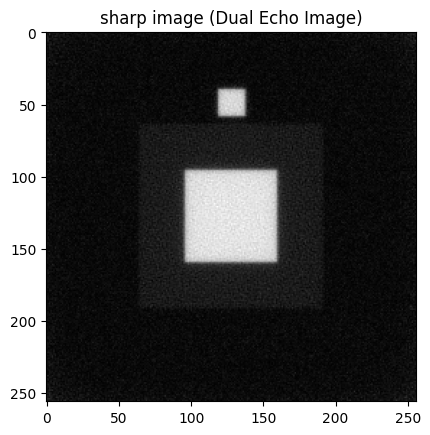

In [55]:
dual_echo_numpy = image_sharp_combined_TE2 - image_sharp_combined_TE1
plt.imshow(np.absolute(dual_echo_numpy))
plt.gray()
plt.title('sharp image (Dual Echo Image)')
plt.show()

## 4. Artefact and Background ROI Extraction

### (1) Artefact ROI 

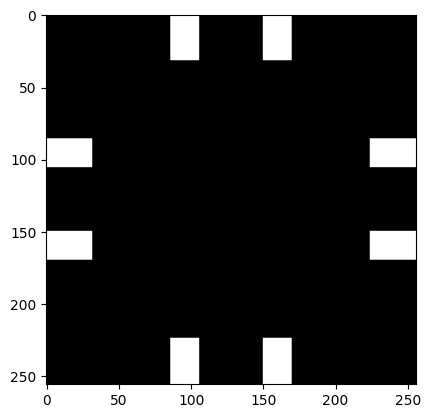

In [56]:
width = 10
vp = pt.VirtualPhantom(img_size)
artefact_ROI = vp.create_artefact_ROI_region(width)
plt.imshow(artefact_ROI, cmap='gray', vmin=0, vmax=1)



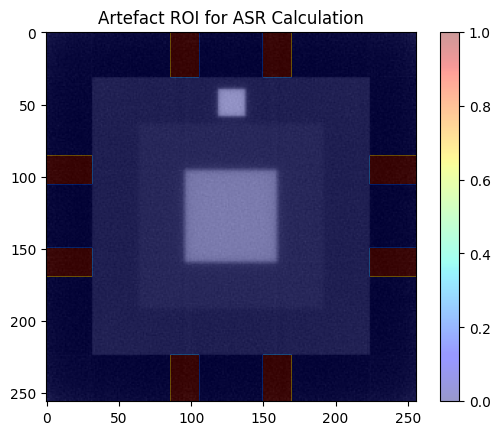

In [57]:
width = 10
vp = pt.VirtualPhantom(img_size)
artefact_ROI = vp.create_artefact_ROI_region(width)

plt.imshow(np.absolute(image_sharp_combined_TE1), cmap='gray')
plt.imshow(artefact_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
plt.title('Artefact ROI for ASR Calculation')
plt.colorbar()
plt.axis('on')
plt.show()

### (2) Background ROI

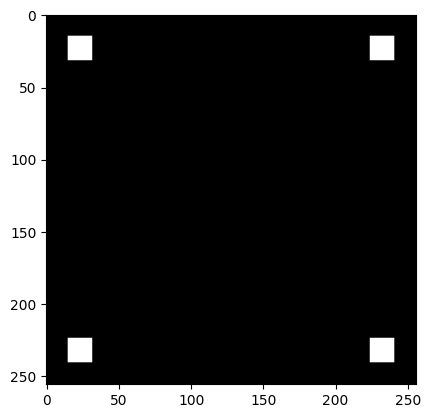

In [58]:
vp = pt.VirtualPhantom(img_size)

background_ROI = vp.create_background_ROI_region()
plt.imshow(background_ROI, cmap='gray', vmin=0, vmax=1)

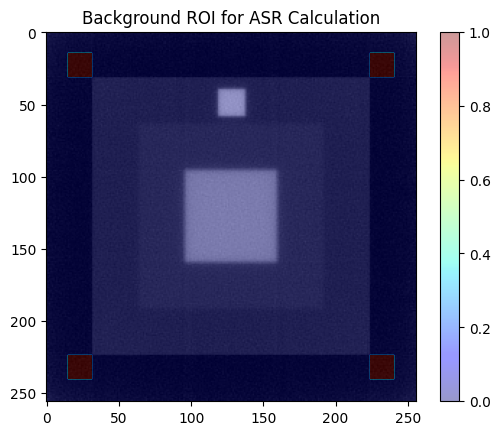

In [59]:
vp = pt.VirtualPhantom(img_size)
background_ROI = vp.create_background_ROI_region()

plt.imshow(np.absolute(image_sharp_combined_TE1), cmap='gray')
plt.imshow(background_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
plt.title('Background ROI for ASR Calculation')
plt.colorbar()
plt.axis('on')
plt.show()

artefact_ROI_mean: 67.13672969762851
background_ROI_mean: 69.79242276824546
myelin mean: 1378.5334604611137


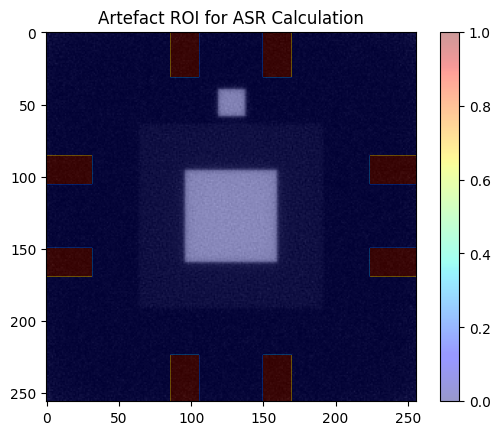

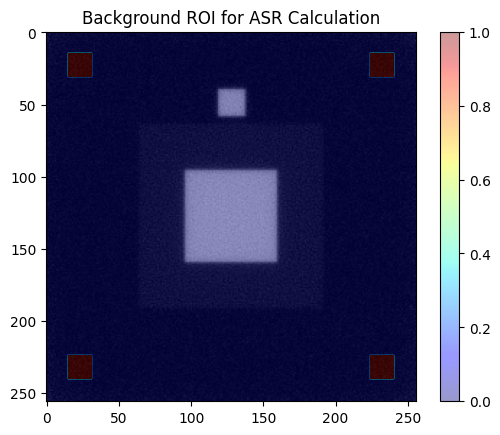

In [60]:
dual_echo_numpy = np.absolute(dual_echo_numpy)

ar = pt.VirtualPhantom(img_size)
myelin_mean = np.mean(dual_echo_numpy[(prob_map_myelin == 1) & (prob_map_wm == 0)])
artefact_ROI = ar.create_artefact_ROI_region(10)
background_ROI = ar.create_background_ROI_region()
artefact_ROI_mean = np.mean(dual_echo_numpy[artefact_ROI == 1])
background_ROI_mean = np.mean(dual_echo_numpy[background_ROI == 1])
asr = (artefact_ROI_mean - background_ROI_mean)/myelin_mean

print("artefact_ROI_mean:", artefact_ROI_mean)
print("background_ROI_mean:", background_ROI_mean)
print("myelin mean:", myelin_mean)
plt.imshow(np.absolute(dual_echo_numpy), cmap='gray')
plt.imshow(artefact_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
plt.title('Artefact ROI for ASR Calculation')
plt.colorbar()
plt.axis('on')
plt.show()

plt.imshow(np.absolute(dual_echo_numpy), cmap='gray')
plt.imshow(background_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
plt.title('Background ROI for ASR Calculation')
plt.colorbar()
plt.axis('on')
plt.show()